In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/performance_cleaned.csv")
df.head()

,Student_ID,Subject,Exam_Score,Homework_Completion_%,Teacher_Comments,Exam_Status,Academic_Grade,Homework_Effort_Group,Academic_Risk_Flag
0,S00002,Arabic,69,95,Season end color son page their begin return t...,Pass,Average,Medium Effort,0
1,S00002,History,98,90,Sport beyond wait feel chair benefit section a...,Pass,Excellent,Medium Effort,0
2,S00003,History,63,95,Drive friend official house one approach troub...,Pass,Below Average,Medium Effort,0
3,S00004,English,100,95,Big everything sure identify happy church coun...,Pass,Excellent,Medium Effort,0
4,S00004,History,59,90,Recognize tell arrive toward collection contin...,Pass,Below Average,Medium Effort,0


### Phân tích khám phá (EDA) trên bộ dữ liệu kết quả học tập nhằm: 
* (1) mô tả hình dạng phân bổ điểm thi và mức độ hoàn thành bài tập; 
* (2) so sánh hiệu suất giữa các môn học; 
* (3) kiểm tra mối liên hệ giữa nỗ lực làm bài tập và kết quả thi; nhằm hỗ trợ trung tâm đào tạo xây dựng hệ thống cảnh báo sớm học viên có nguy cơ học tập kém.

### 3–5 câu hỏi phân tích trọng tâm 
1. Exam_Score và Homework_Completion_% có hình dạng phân bổ như thế nào? Có tồn tại outlier không?
2. Kết quả thi (Exam_Score) có khác biệt đáng kể giữa 6 môn học (Subject) hay không?
3. Mức độ hoàn thành bài tập (Homework_Effort_Group) có tương quan với điểm thi cuối kỳ không?
4. Tỷ lệ học viên rơi vào nhóm rủi ro học tập (Academic_Risk_Flag) có khác nhau giữa các môn không?
5. Cơ cấu học lực (Academic_Grade) phân bổ ra sao trên toàn bộ dữ liệu?

In [2]:
df["Subjects_per_Student"] = df.groupby("Student_ID")["Subject"].transform("count")

In [3]:
def describe_full(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    return pd.Series({
        "count": series.count(),
        "missing_%": series.isna().mean() * 100,
        "mean": series.mean(),
        "median": series.median(),
        "std": series.std(),
        "min": series.min(),
        "Q1": q1,
        "Q3": q3,
        "max": series.max(),
        "skewness": series.skew(),
    })

vars3 = ["Exam_Score", "Homework_Completion_%", "Subjects_per_Student"]
summary_table = pd.DataFrame({v: describe_full(df[v]) for v in vars3}).T
summary_table

,count,missing_%,mean,median,std,min,Q1,Q3,max,skewness
Exam_Score,28736.0,0.0,76.913384,79.0,19.148812,40.0,61.0,96.0,100.0,-0.329753
Homework_Completion_%,28736.0,0.0,91.994188,95.0,6.795755,80.0,90.0,95.0,100.0,-0.754122
Subjects_per_Student,28736.0,0.0,2.962347,3.0,1.083230,1.0,2.0,4.0,6.0,0.162433


In [4]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for v in vars3:
    low, high = iqr_bounds(df[v])
    n_out = ((df[v] < low) | (df[v] > high)).sum()
    print(f"{v}: ngưỡng hợp lệ [{low:.1f}, {high:.1f}] — {n_out} outlier ({n_out/len(df)*100:.2f}%)")

Exam_Score: ngưỡng hợp lệ [8.5, 148.5] — 0 outlier (0.00%)
Homework_Completion_%: ngưỡng hợp lệ [82.5, 102.5] — 5796 outlier (20.17%)
Subjects_per_Student: ngưỡng hợp lệ [-1.0, 7.0] — 0 outlier (0.00%)


## Biểu đồ 1 — Histogram 

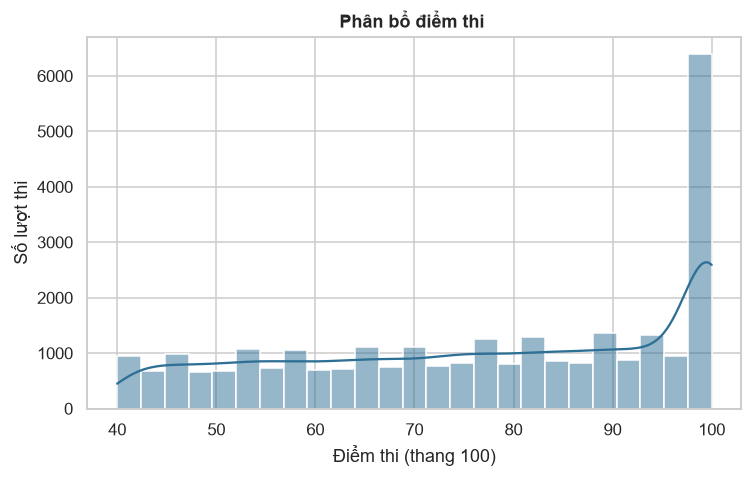

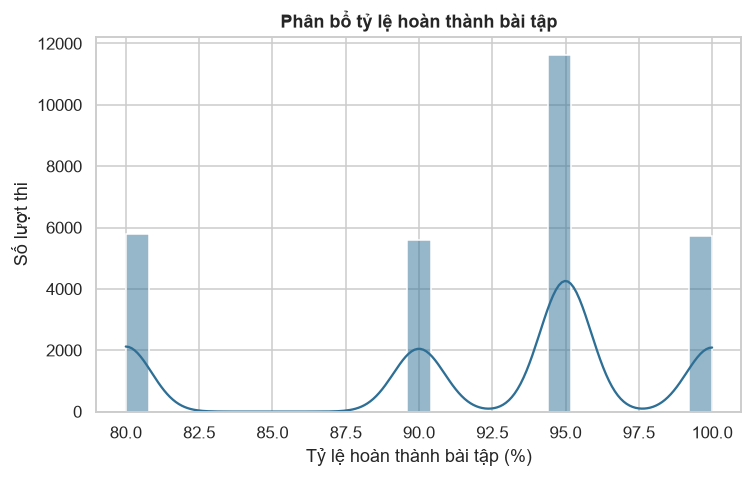

In [8]:
vars_to_plot = {
    "Exam_Score": {
        "label": "Điểm thi (thang 100)",
        "hist_title": "Phân bổ điểm thi ",
        "box_title": "Boxplot Exam_Score: khoảng IQR và outlier phía dưới",
        "hist_file": "01_hist_exam_score.png",
        "box_file": "02_box_exam_score.png",
    },
    "Homework_Completion_%": {
        "label": "Tỷ lệ hoàn thành bài tập (%)",
        "hist_title": "Phân bổ tỷ lệ hoàn thành bài tập",
        "box_title": "Boxplot Homework_Completion_%: khoảng IQR và outlier",
        "hist_file": "07_hist_hw_completion.png",
        "box_file": "07b_box_hw_completion.png",
    },
}

for col, cfg in vars_to_plot.items():
    # Histogram
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.histplot(df[col], bins=25, kde=True, color="#2E6F95", ax=ax)
    ax.set_title(cfg["hist_title"], fontsize=12, weight="bold")
    ax.set_xlabel(cfg["label"])
    ax.set_ylabel("Số lượt thi")
    plt.tight_layout()
    plt.savefig(f"../figures/{cfg['hist_file']}", dpi=150)
    plt.show()

## Biểu đồ 2 — Boxplot 

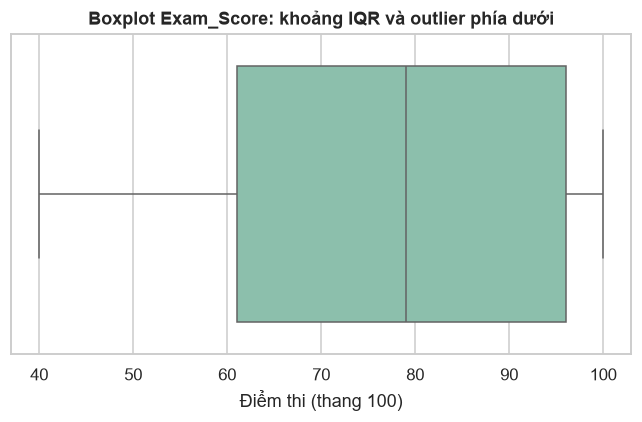

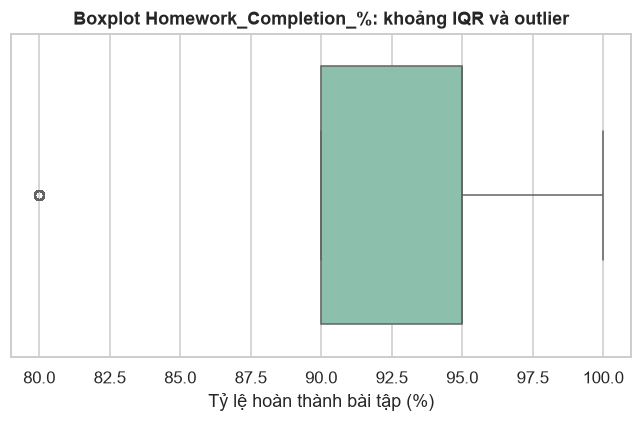

In [9]:
for col, cfg in vars_to_plot.items():    
    # Boxplot
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(x=df[col], color="#84C7AE", ax=ax)
    ax.set_title(cfg["box_title"], fontsize=12, weight="bold")
    ax.set_xlabel(cfg["label"])
    plt.tight_layout()
    plt.savefig(f"../figures/{cfg['box_file']}", dpi=150)
    plt.show()

## Nhận định:

In [11]:
for col in ["Exam_Score", "Homework_Completion_%"]:
    s = df[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((s < low) | (s > high)).sum()
    print(f"--- {col} ---")
    print(f"mean={s.mean():.2f}, median={s.median():.2f}, skew={s.skew():.2f}")
    print(f"Q1={q1}, Q3={q3}, IQR bounds=[{low:.2f}, {high:.2f}]")
    print(f"outliers: {n_out} ({n_out/len(s)*100:.2f}%)\n")

--- Exam_Score ---
mean=76.91, median=79.00, skew=-0.33
Q1=61.0, Q3=96.0, IQR bounds=[8.50, 148.50]
outliers: 0 (0.00%)

--- Homework_Completion_% ---
mean=91.99, median=95.00, skew=-0.75
Q1=90.0, Q3=95.0, IQR bounds=[82.50, 102.50]
outliers: 5796 (20.17%)



### Exam_Score:

Điểm thi có mean = 76.91, median = 79.00 (median > mean, skew = -0.33) → phân bổ lệch trái nhẹ, đa số học viên đạt điểm khá-giỏi, một bộ phận nhỏ điểm thấp kéo dài đuôi trái. Theo phương pháp IQR, ngưỡng hợp lệ là [8.5, 148.5] — 0 outlier. Điều này cho thấy dù histogram có vẻ "chất đống" ở vùng điểm cao, về mặt thống kê không có giá trị nào bất thường: khoảng biến thiên thực tế (40–100) nằm gọn trong ngưỡng cho phép vì IQR (Q3−Q1 = 35 điểm) khá rộng.

### Homework_Completion_%:

Biến này chỉ nhận 4 giá trị rời rạc (80/90/95/100), mean = 91.99, median = 95.00, skew = -0.75 (lệch trái rõ hơn Exam_Score). Q1 = 90, Q3 = 95 → IQR rất hẹp (chỉ 5 điểm phần trăm), khiến ngưỡng dưới chỉ là 82.5. Vì vậy toàn bộ 5.796 lượt (20.17%) có giá trị 80% bị xác định là outlier — đây là một trường hợp kinh điển cho thấy IQR nhạy với dữ liệu có ít giá trị rời rạc và phân bổ hẹp: về bản chất 80% không phải là lỗi hay bất thường, mà là một mức hoàn thành bài tập hợp lệ (tương ứng nhóm Low Effort), chỉ là hiếm hơn so với phần đông học viên đạt 90-100%. Cần nêu rõ điều này để tránh hiểu nhầm "outlier = lỗi dữ liệu".

### Câu hỏi: Exam_Score có khác biệt giữa các Subject không?

In [10]:
group_stats = df.groupby("Subject", observed=True)["Exam_Score"].agg(
    count="count", mean="mean", median="median", std="std"
).sort_values("mean", ascending=False)
group_stats

,count,mean,median,std
Subject,,,,
Science,4802,77.135985,80.0,19.049646
History,4708,77.132116,80.0,19.229573
English,4784,77.114548,80.0,19.111408
Arabic,4868,77.044988,80.0,19.185464
Geography,4792,76.584516,79.0,19.137212
Math,4782,76.468841,78.0,19.178064


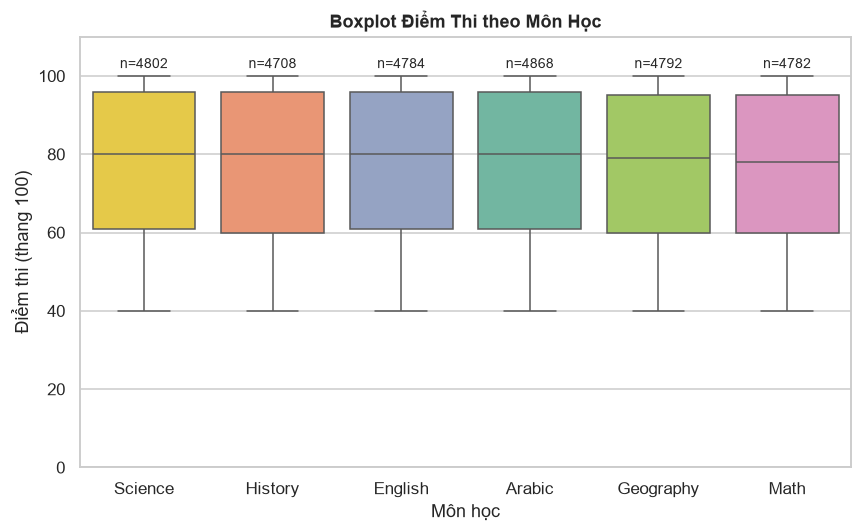

In [14]:
order = group_stats.index
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x="Subject", y="Exam_Score", order=order,
            hue="Subject", palette="Set2", legend=False, ax=ax)
for i, subj in enumerate(order):
    n = group_stats.loc[subj, "count"]
    ax.text(i, 102, f"n={int(n)}", ha="center", fontsize=9)
ax.set_ylim(0, 110)
ax.set_title("Boxplot Điểm Thi theo Môn Học", fontsize=12, weight="bold")
ax.set_xlabel("Môn học")
ax.set_ylabel("Điểm thi (thang 100)")
plt.tight_layout()
plt.savefig("../figures/03_box_examscore_by_subject.png", dpi=150)

Bảng thống kê theo Subject cho thấy cỡ mẫu khá cân bằng (n dao động 4708–4868 lượt/môn). Điểm trung bình dao động rất hẹp, từ 76.47 (Math) đến 77.14 (Science) — chênh lệch chỉ 0.67 điểm, nhỏ hơn nhiều so với độ lệch chuẩn nội nhóm (~19 điểm). 

Boxplot minh họa trực quan: phân bổ điểm của cả 6 môn gần như trùng khớp (median 78-80, khoảng biến thiên 40-100 giống hệt nhau). Kết luận: không có bằng chứng cho thấy sự khác biệt có ý nghĩa thực tế giữa các môn học — dù n đủ lớn để phát hiện khác biệt nhỏ nếu có, chênh lệch quan sát được quá nhỏ so với độ phân tán tự nhiên của điểm số để có ý nghĩa phân tích.

# Phân tích mối quan hệ 

In [15]:
from scipy import stats

r, p_value = stats.pearsonr(df["Homework_Completion_%"], df["Exam_Score"])
print(f"Pearson r = {r:.3f}, p-value = {p_value:.4f}")

Pearson r = 0.003, p-value = 0.6659


Hệ số tương quan Pearson giữa Homework_Completion_% và Exam_Score là r = 0.003 (p = 0.666) - không có mối liên hệ tuyến tính nào có ý nghĩa thống kê giữa hai biến. 


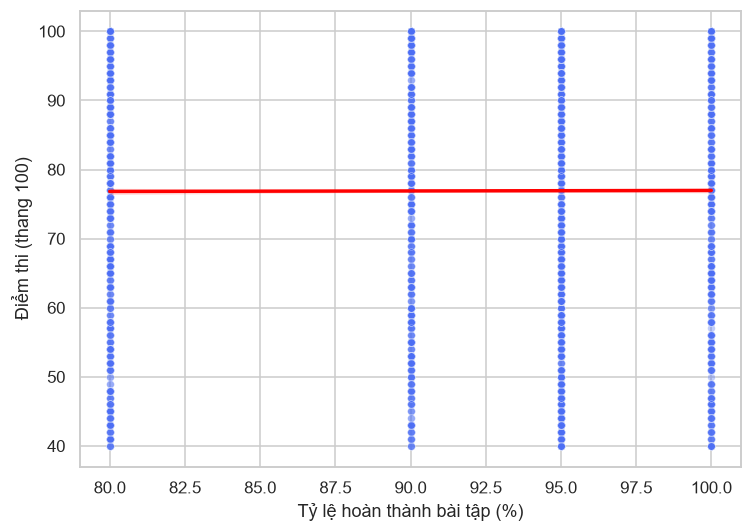

In [17]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=df.sample(3000, random_state=42), x="Homework_Completion_%", y="Exam_Score",
                 alpha=0.35, s=25, color="#4C6EF5", ax=ax)
sns.regplot(data=df, x="Homework_Completion_%", y="Exam_Score", scatter=False, color="red", ax=ax)
ax.set_xlabel("Tỷ lệ hoàn thành bài tập (%)")
ax.set_ylabel("Điểm thi (thang 100)")
plt.tight_layout()
plt.savefig("../figures/04_scatter_hw_vs_exam.png", dpi=150)

Biểu đồ scatter xác nhận trực quan: tại cả 4 mức hoàn thành bài tập (80%, 90%, 95%, 100%), điểm thi đều trải rộng từ 40 đến 100 với phân bổ gần như giống hệt nhau; đường hồi quy gần như nằm ngang. Kết quả này bác bỏ giả thuyết ban đầu (câu hỏi phân tích #3) rằng nỗ lực làm bài tập có liên hệ với kết quả thi. Vì hệ số tương quan không có ý nghĩa thống kê, không cần và không nên bàn đến quan hệ nhân quả ở đây — dữ liệu đơn giản là không cho thấy association giữa hai biến này.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10416\912015558.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trend.index, y=trend.values, palette="Blues_d", ax=ax)


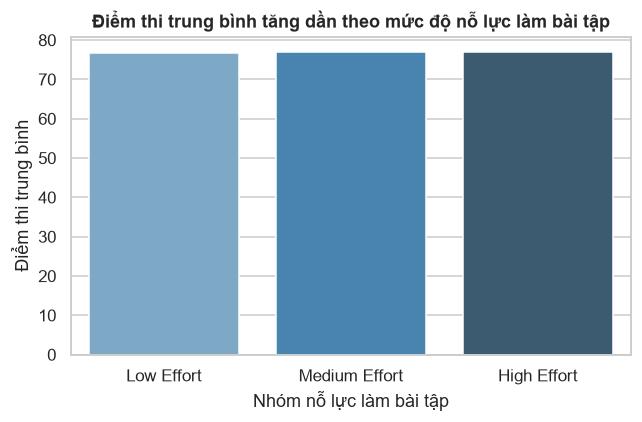

In [18]:
order_effort = ["Low Effort", "Medium Effort", "High Effort"]
trend = df.groupby("Homework_Effort_Group", observed=True)["Exam_Score"].mean().reindex(order_effort)

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=trend.index, y=trend.values, palette="Blues_d", ax=ax)
ax.set_title("Điểm thi trung bình tăng dần theo mức độ nỗ lực làm bài tập", fontsize=12, weight="bold")
ax.set_ylabel("Điểm thi trung bình")
ax.set_xlabel("Nhóm nỗ lực làm bài tập")
plt.tight_layout()
plt.savefig("../figures/06_bar_examscore_by_effort.png", dpi=150)

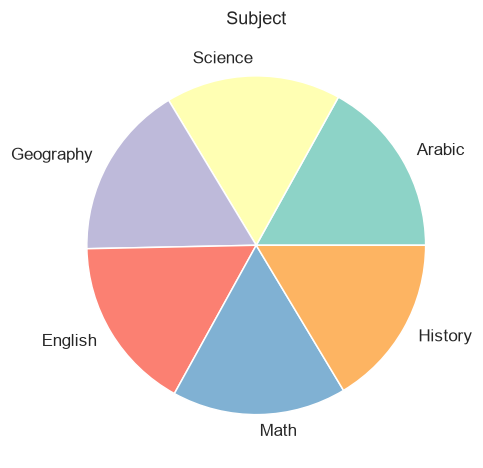

In [19]:
# Before (Kém)
counts = df["Subject"].value_counts()
fig, ax = plt.subplots(figsize=(5,5))
ax.pie(counts, labels=counts.index, colors=sns.color_palette("Set3"))
ax.set_title("Subject")
plt.savefig("../figures/05a_before_pie.png", dpi=150)

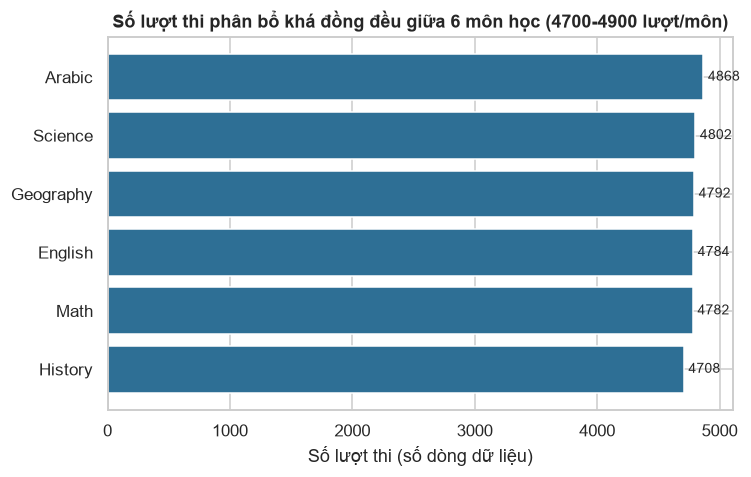

In [20]:
# After (Tốt)
fig, ax = plt.subplots(figsize=(7,4.5))
counts_sorted = counts.sort_values(ascending=True)
bars = ax.barh(counts_sorted.index, counts_sorted.values, color="#2E6F95")
ax.set_title("Số lượt thi phân bổ khá đồng đều giữa 6 môn học (4700-4900 lượt/môn)", fontsize=12, weight="bold")
ax.set_xlabel("Số lượt thi (số dòng dữ liệu)")
ax.bar_label(bars, padding=3, fontsize=9)
plt.tight_layout()
plt.savefig("../figures/05b_after_bar.png", dpi=150)

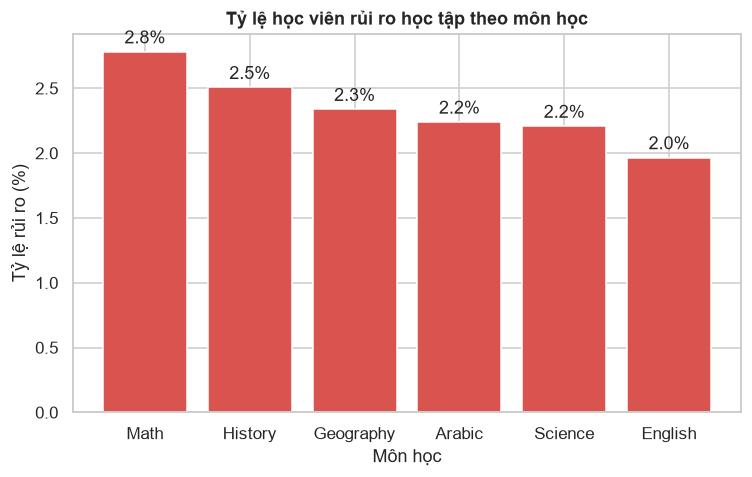

In [21]:
risk_by_subject = df.groupby("Subject", observed=True)["Academic_Risk_Flag"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(risk_by_subject.index, risk_by_subject.values, color="#D9534F")
ax.set_title("Tỷ lệ học viên rủi ro học tập theo môn học", fontsize=12, weight="bold")
ax.set_xlabel("Môn học")
ax.set_ylabel("Tỷ lệ rủi ro (%)")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
plt.tight_layout()
plt.savefig("../figures/08_bar_riskflag_by_subject.png", dpi=150)

In [4]:
import pandas as pd
geo = df[df['Subject']=='Geography']
print(len(geo), geo['Exam_Score'].mean())

4792 76.58451585976627
